# Credit Default Risk for Digital Lenders
## An analytical exercise to simulate how a data-driven FinTech builds credit-risk signals from real borrower behaviour. Analyse, model, and present findings from the UCI Credit Card Default dataset.

## 1) EDA
###  Importing required libraries and data

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Load the data
df = pd.read_csv(r'D:\assignment\Credit-Default-Risk_(Vitto)\data\UCI_Credit_Card.csv')

In [2]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
print(df.shape)
print(df.dtypes) # No categorical variable present in the dataset, all are numerical.
# df.isnull().sum()  
# # NO empty cell present in the dataset 

(30000, 25)
ID                              int64
LIMIT_BAL                     float64
SEX                             int64
EDUCATION                       int64
MARRIAGE                        int64
AGE                             int64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
default.payment.next.month      int64
dtype: object


In [4]:
df['default.payment.next.month'].value_counts()

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

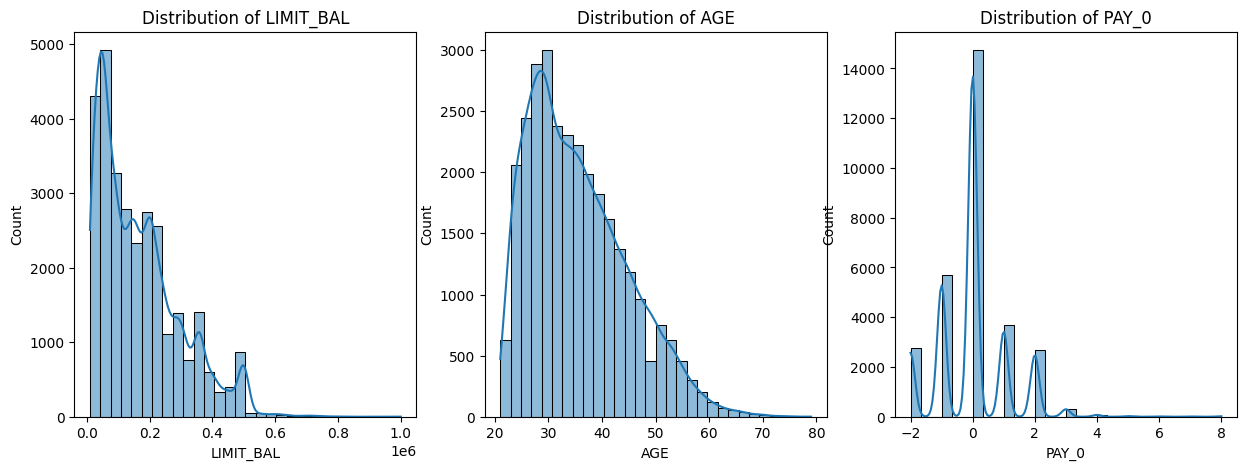

In [5]:
# Plot distributions of LIMIT_BAL, AGE, and PAY_0; flag any anomalies.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)
plt.title('Distribution of LIMIT_BAL')

plt.subplot(1, 3, 2)
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Distribution of AGE')

plt.subplot(1, 3, 3)
sns.histplot(df['PAY_0'], bins=30, kde=True)
plt.title('Distribution of PAY_0')

plt.show()

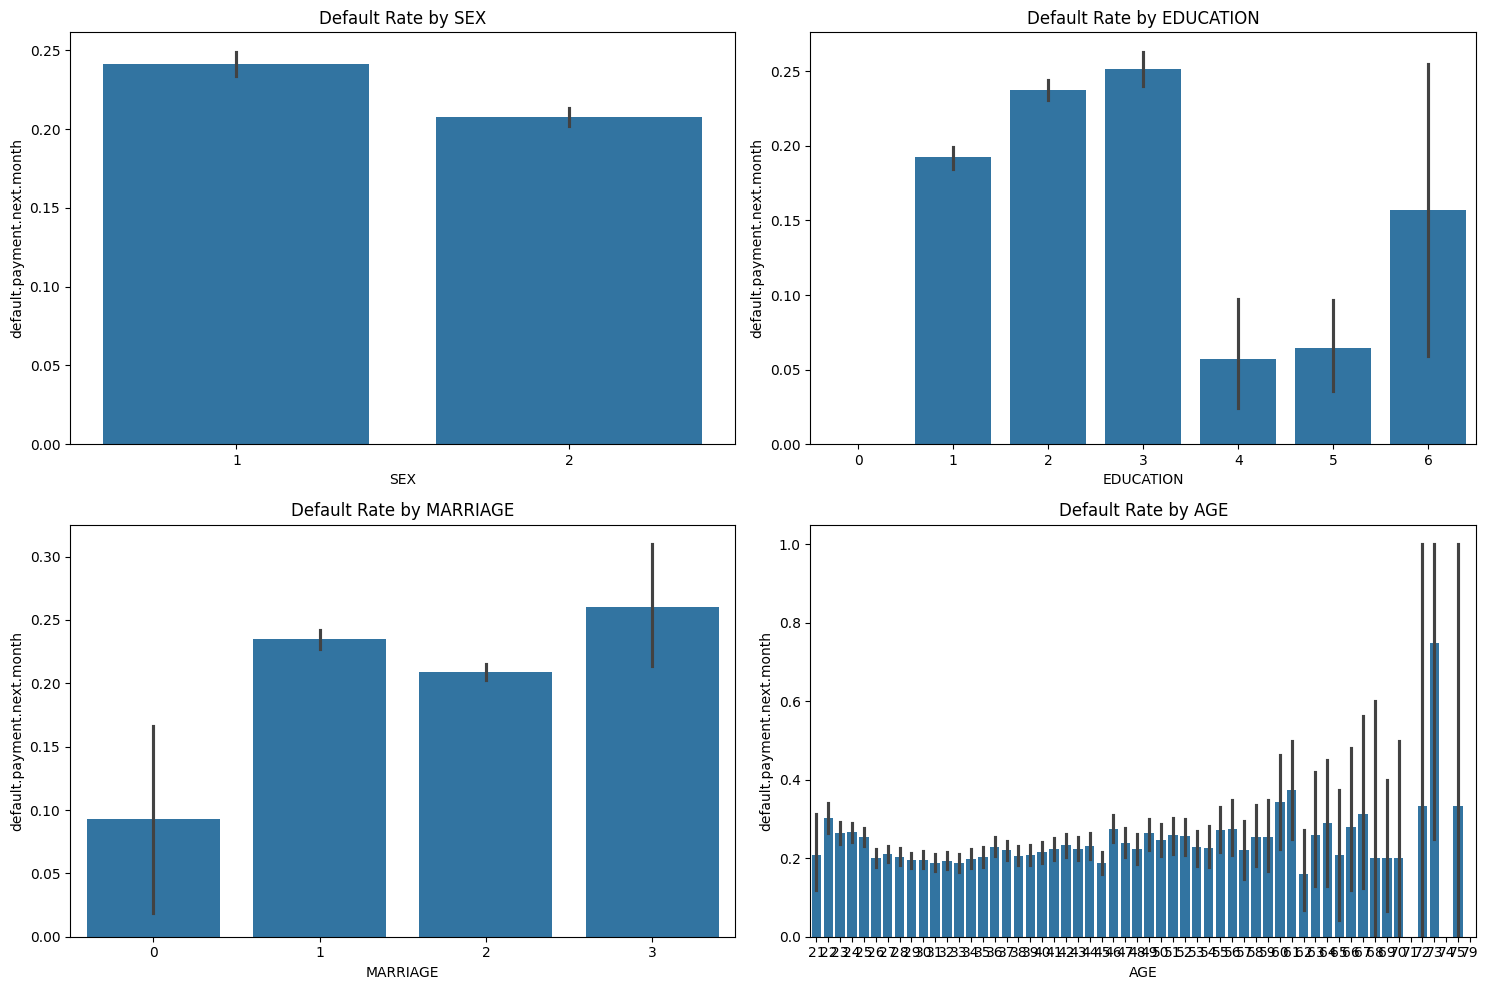

In [6]:
# Compare default rates across SEX, EDUCATION, MARRIAGE, and AGE bands.

plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)    
sns.barplot(x='SEX', y='default.payment.next.month', data=df)
plt.title('Default Rate by SEX')

plt.subplot(2, 2, 2)
sns.barplot(x='EDUCATION', y='default.payment.next.month', data=df)
plt.title('Default Rate by EDUCATION')

plt.subplot(2, 2, 3)
sns.barplot(x='MARRIAGE', y='default.payment.next.month', data=df)
plt.title('Default Rate by MARRIAGE')

plt.subplot(2, 2, 4)
sns.barplot(x='AGE', y='default.payment.next.month', data=df)
plt.title('Default Rate by AGE')
plt.tight_layout()

plt.show()

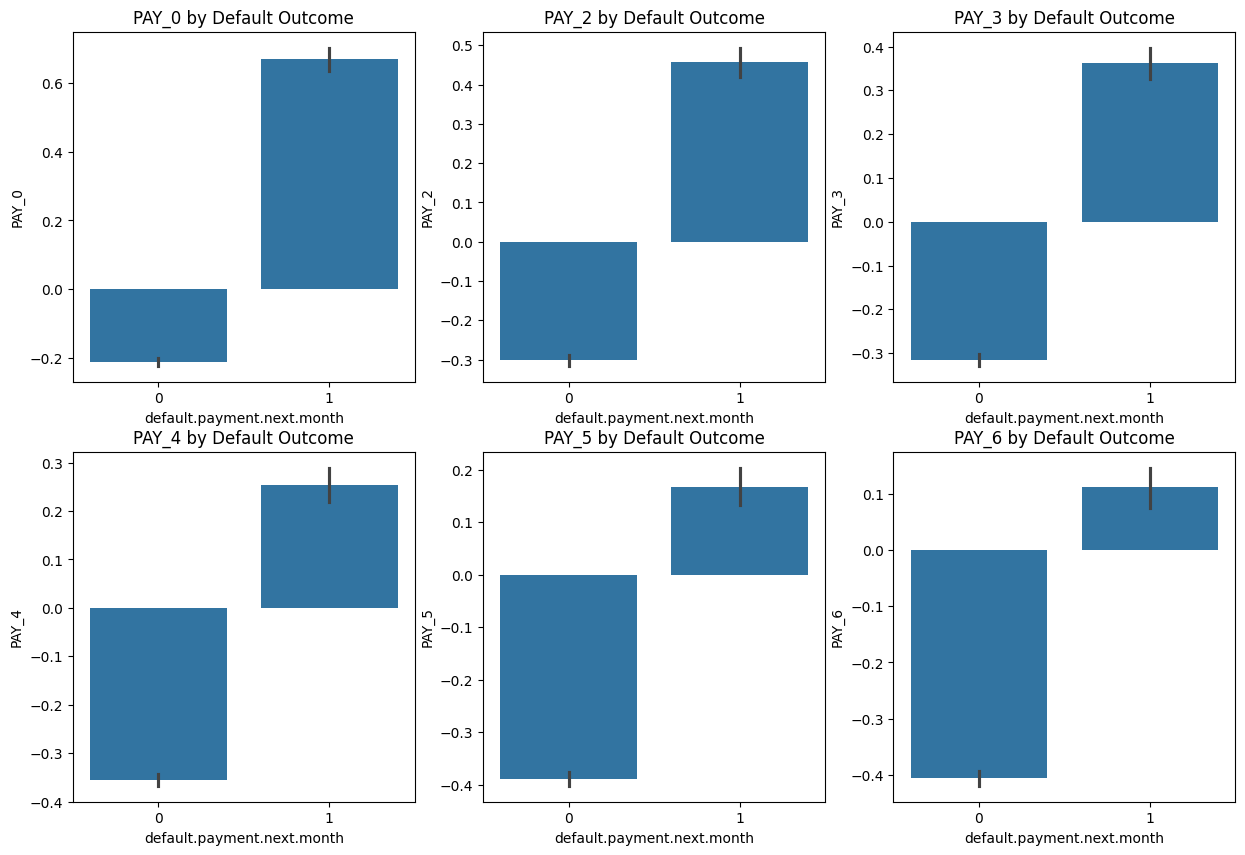

In [7]:
# Visualise repayment delay patterns across PAY_0 to PAY_6 by default outcome.

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
plt.figure(figsize=(15, 10))
for i, col in enumerate(pay_cols):
    plt.subplot(2, 3, i+1)
    sns.barplot(x='default.payment.next.month', y=col, data=df)
    plt.title(f'{col} by Default Outcome')

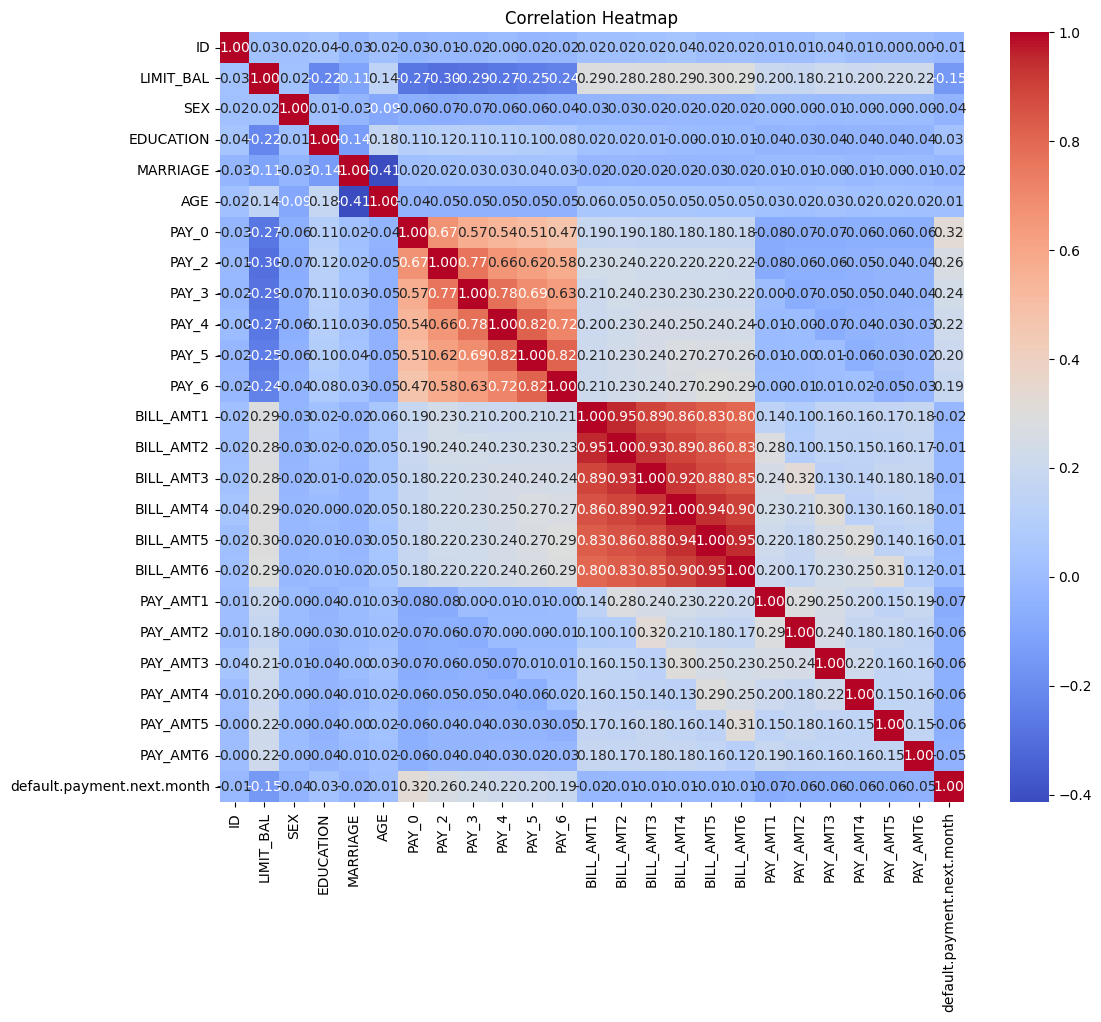

Top 5 features most correlated with default.payment.next.month:
PAY_0    0.324794
PAY_2    0.263551
PAY_3    0.235253
PAY_4    0.216614
PAY_5    0.204149
Name: default.payment.next.month, dtype: float64


In [8]:
# Correlation heatmap; identify top 5 features associated with default.
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
print("Top 5 features most correlated with default.payment.next.month:")
print(corr['default.payment.next.month'].abs().sort_values(ascending=False).head(6)[1:])

## 2) Feature Engineering

In [9]:
# Create AVG_UTIL_RATE = mean(BILL_AMTx / LIMIT_BAL) across 6 months — measures credit utilisation.
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df['AVG_UTIL_RATE'] = df[bill_cols].div(df['LIMIT_BAL'], axis=0).mean(axis=1)



# Create TOTAL_DELAY_MONTHS = count of PAY_x values &gt; 0 — cumulative delinquency signal.
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['TOTAL_DELAY_MONTHS'] = df[pay_cols].gt(0).sum(axis=1)

# Encode EDUCATION (merge values 0, 5, 6 into 'other') and MARRIAGE (merge 0 into 'other').
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})


In [10]:
# Create AVG_PAY_RATIO = mean(PAY_AMTx / BILL_AMTx where BILL_AMTx>0) — repayment consistency.
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
# Replace bill amounts <= 0 with NaN
bill_values = df[bill_cols].replace(0, np.nan).to_numpy()

pay_values = df[pay_amt_cols].to_numpy()
pay_ratio = pay_values / bill_values

# Row-wise average ignoring NaN
df['AVG_PAY_RATIO'] = np.nanmean(pay_ratio, axis=1)
df['AVG_PAY_RATIO'] = df['AVG_PAY_RATIO'].fillna(0)

### Jutification on applied feature engineering

### 1. AVG_UTIL_RATE: This feature captures the average credit utilisation over the past 6 months. High utilisation rates can indicate financial stress and a higher likelihood of default.
### 2. AVG_PAY_RATIO: This feature measures the average repayment ratio, which indicates how consistently a customer has been making payments relative to their billed amounts. A low ratio may signal repayment difficulties.
### 3. TOTAL_DELAY_MONTHS: This feature counts the number of months with delayed payments, providing a cumulative signal of delinquency. More delayed months can indicate a higher risk of default.
### 4. Encoding EDUCATION and MARRIAGE: Merging less common categories into 'other' helps to reduce noise and improve model performance by ensuring that the model focuses on the most relevant categories without being skewed by rare occurrences.  


## 3) Model Development

In [11]:
# Train a Logistic Regression baseline; report Precision, Recall, F1, and AUC-ROC.
X = df.drop(columns=['ID', 'default.payment.next.month'])
y = df['default.payment.next.month']


In [23]:

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
xgb_clf = XGBClassifier(class_weight='balanced', random_state=42)
models = {
    "LogisticRegression": Pipeline([("model", log_reg)]),
    "XGClassifier": Pipeline([("model", xgb_clf)]),
}


In [26]:
# 5-fold stratified CV (AUC-ROC)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results.append((name, scores.mean(), scores.std()))
    print(f"{name} CV AUC-ROC: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results, columns=["Model", "CV_AUC_Mean", "CV_AUC_Std"]).sort_values("CV_AUC_Mean", ascending=False)
display(cv_df)

best_model_name = cv_df.iloc[0]["Model"]
best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_train)

# Evaluate both models on holdout test set
eval_rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    eval_rows.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC_ROC": roc_auc_score(y_test, y_prob),
    })


LogisticRegression CV AUC-ROC: 0.6572 ± 0.0048
XGClassifier CV AUC-ROC: 0.7652 ± 0.0087


,Model,CV_AUC_Mean,CV_AUC_Std
1,XGClassifier,0.765186,0.008727
0,LogisticRegression,0.657240,0.004816


### Here, using a weight balance is a better approach because : 
#### 1) Gives penalty to the misclassification of the minority class without altering the original data distribution, thus preserving the natural relationships in the data.
#### 2) The ratio is not extremely imbalanced (22% default rate), so adjusting class weights can be sufficient to improve model performance without the need for synthetic data generation.
#### 3) SMOTE can sometimes lead to overfitting given it uses linear interpolation to create synthetic samples, which may not capture the true complexity of the data, especially if the minority class has a complex distribution.
#### 4) Helps in lowering leakage and for simplicity.

In [27]:
# Top 5 features from the best model (XGBoost) based on feature importance.
if best_model_name == "XGClassifier":
    xgb_model = best_pipe.named_steps["model"]
    feature_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
    top_features = feature_importances.sort_values(ascending=False).head(5)
    print("Top 5 features from XGBoost based on feature importance:")
    print(top_features)

Top 5 features from XGBoost based on feature importance:
TOTAL_DELAY_MONTHS    0.313072
PAY_0                 0.272298
AVG_UTIL_RATE         0.020669
EDUCATION             0.020371
PAY_AMT2              0.020291
dtype: float32


#### We can see 2 features are from feature engnn are taken as important 

## 4) Visualization and Communication

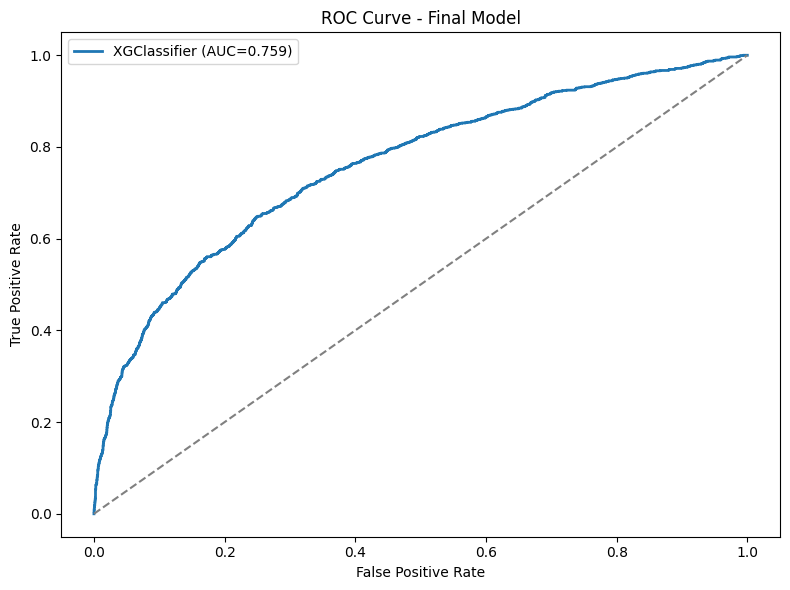

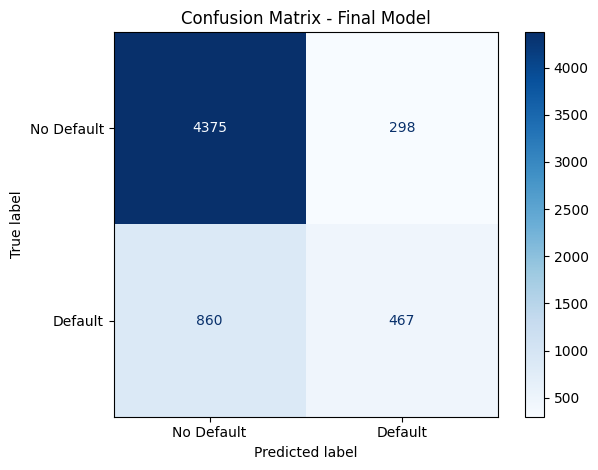

In [32]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

best_model_name = cv_df.iloc[0]["Model"]
best_pipe = models[best_model_name]


y_pred_best = best_pipe.predict(X_test)
y_prob_best = best_pipe.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={roc_auc_score(y_test, y_prob_best):.3f})", lw=2)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Final Model")
plt.tight_layout()
plt.show()

### Write-up summary

We analyzed 30,000 credit card customers to identify who is most likely to miss next month’s payment.
The strongest warning signs were repeated repayment delays, high average credit utilization, and weak repayment
consistency against monthly bills. In simple terms: customers who frequently pay late, use a high share of their
available limit, and repay only a small part of what they owe are much more likely to default.

We compared a baseline logistic regression model with a XGBClassifier model using a stratified 5-fold approach.
The tree-based model performed better on AUC-ROC while maintaining practical precision/recall balance, so we used it
as the final model. Because defaults are a minority class (about 22%), we used class-balanced training weights to avoid
a model that over-focuses on non-defaults.

Data quality was handled explicitly: undocumented education and marriage codes were consolidated into “other,” and
negative bill values (overpayments) were flagged and incorporated carefully in engineered features. The resulting model
is suitable for ranking risk, not for automatic declines without policy controls.

**Two concrete actions:**
1. Introduce an “early-warning” workflow for customers with multiple recent delay months and rising utilization
   (proactive reminders, payment plans, or limit review).
2. Add repayment-ratio and delay-based thresholds to credit line increase decisions, so high-risk behavior slows
   exposure growth while stable payers receive more favorable treatment.